### Strategy 1st try 

Investment horizon : 5 days 

Strategy 1: 
Compare predicted volatility to avg. volatility 
Open Butterfly long if pred_vol < avg_vol

Strategy 2: 
Compare predicted volatility to implied volatility
Open Butterfly long if pred_vol < IV





In [3]:
# %pip install py_vollib

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from py_vollib.black_scholes import black_scholes
from scipy.stats import percentileofscore
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import yfinance as yf
from py_vollib.black_scholes import implied_volatility

#### Data import 

In [9]:
path = r"C:\Users\pauli\Downloads\predicted_volatility_5d_horizon.csv"   # fake data for testing 
vol_predictions = pd.read_csv(path)
vol_predictions['predicted_vol'] = vol_predictions['predicted_vol'] *0.1

options_data = pd.read_csv(r"C:\Users\pauli\Butterflies-\options\options.csv")
options_data= options_data.rename(columns={'close' : 'opt_close'}) 
underlying_data= pd.read_csv(r"C:\Users\pauli\Butterflies-\yfinance_data\spy.csv")
underlying_data = underlying_data.iloc[2:]
underlying_data = underlying_data.rename(columns={'Price' : 'timestamp', 'Close' : 'close', 'Volume' : 'volume'})

options_data
#underlying_data
vol_predictions

,prediction_day,predicted_day,predicted_vol
0,2023-12-25,2024-01-01,0.090043
1,2023-12-26,2024-01-01,0.642611
2,2023-12-26,2024-01-02,0.860442
3,2023-12-27,2024-01-01,0.308939
4,2023-12-27,2024-01-02,0.554217
...,...,...,...
1810,2025-05-16,2025-05-19,0.774298
1811,2025-05-16,2025-05-20,0.796587
1812,2025-05-16,2025-05-21,1.160330
1813,2025-05-16,2025-05-22,1.139469


In [3]:
import datetime as dt
import pytz

options_data['expiration_date'] = pd.to_datetime(options_data['expiration_date'])
options_data['timestamp'] = pd.to_datetime(options_data['timestamp'])
options_data["open_interest_date"] = pd.to_datetime(options_data["open_interest_date"])
options_data["close_price_date"] = pd.to_datetime(options_data["close_price_date"])

# add UTC to timestamps 

options_data['expiration_date'] = options_data['expiration_date'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["close_price_date"] = options_data["close_price_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
options_data["open_interest_date"] = options_data["open_interest_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)


# calculate dtm 
options_data['dtm'] = options_data.apply(
    lambda row: np.busday_count(row['timestamp'].date(), row['expiration_date'].date()),
    axis=1
)    #trading_days_to_expiry




In [4]:
# fix datetime and UTC issues 

underlying_data['timestamp'] = pd.to_datetime(underlying_data['timestamp'])
underlying_data['timestamp'] = underlying_data['timestamp'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

vol_predictions["predicted_day"] = pd.to_datetime(vol_predictions["predicted_day"])
vol_predictions["predicted_day"] = vol_predictions["predicted_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)
vol_predictions["prediction_day"] = pd.to_datetime(vol_predictions["prediction_day"])
vol_predictions["prediction_day"] = vol_predictions["prediction_day"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)


# columns to numeric values
# For vol_predictions
vol_predictions['predicted_vol'] = pd.to_numeric(vol_predictions['predicted_vol'], errors='coerce')

# For underlying_data
underlying_data['close'] = pd.to_numeric(underlying_data['close'], errors='coerce')

# For options_data
options_data['opt_close'] = pd.to_numeric(options_data['opt_close'], errors='coerce')
options_data['open_interest'] = pd.to_numeric(options_data['open_interest'], errors='coerce')
options_data['volume'] = pd.to_numeric(options_data['volume'], errors='coerce')
options_data['strike_price'] = pd.to_numeric(options_data['strike_price'], errors='coerce')


In [5]:
# filter timestamps for all dataframes based on the available options 

start_date = options_data['timestamp'].min()
end_date = options_data['timestamp'].max()

vol_predictions = vol_predictions[(vol_predictions['prediction_day'] >= start_date) & (vol_predictions['prediction_day'] <= end_date)]
underlying_data = underlying_data[(underlying_data['timestamp'] >= start_date) & (underlying_data['timestamp'] <= end_date)]

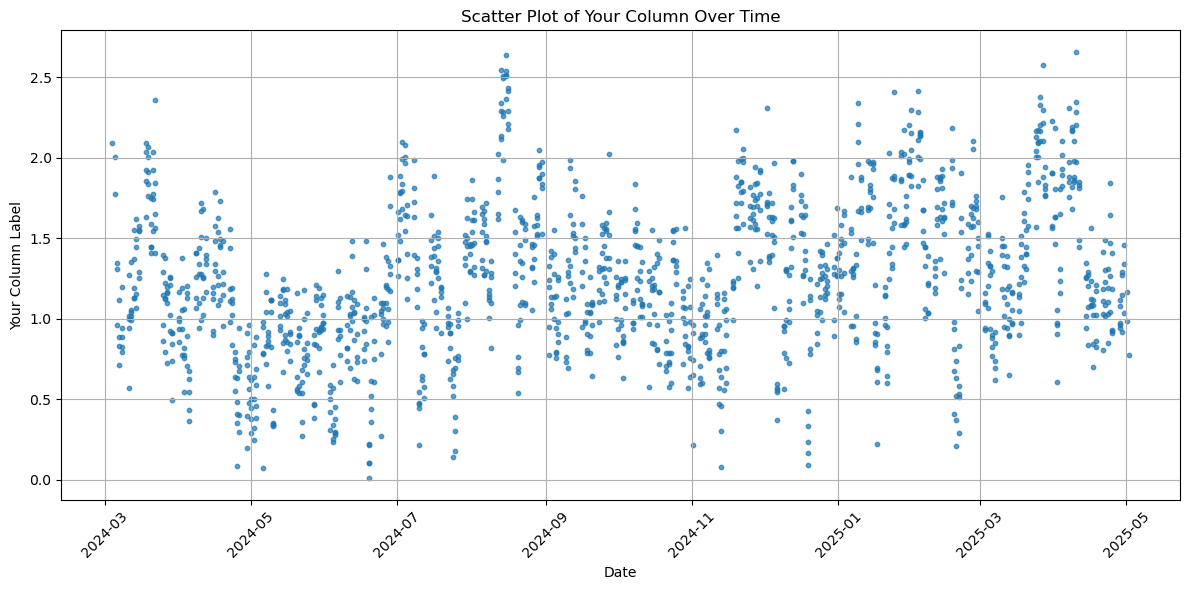

In [6]:
vol_predictions


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.scatter(vol_predictions['predicted_day'], vol_predictions['predicted_vol'], s=10, alpha=0.7)
plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Your Column Label')
plt.title('Scatter Plot of Your Column Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

No trades executed.


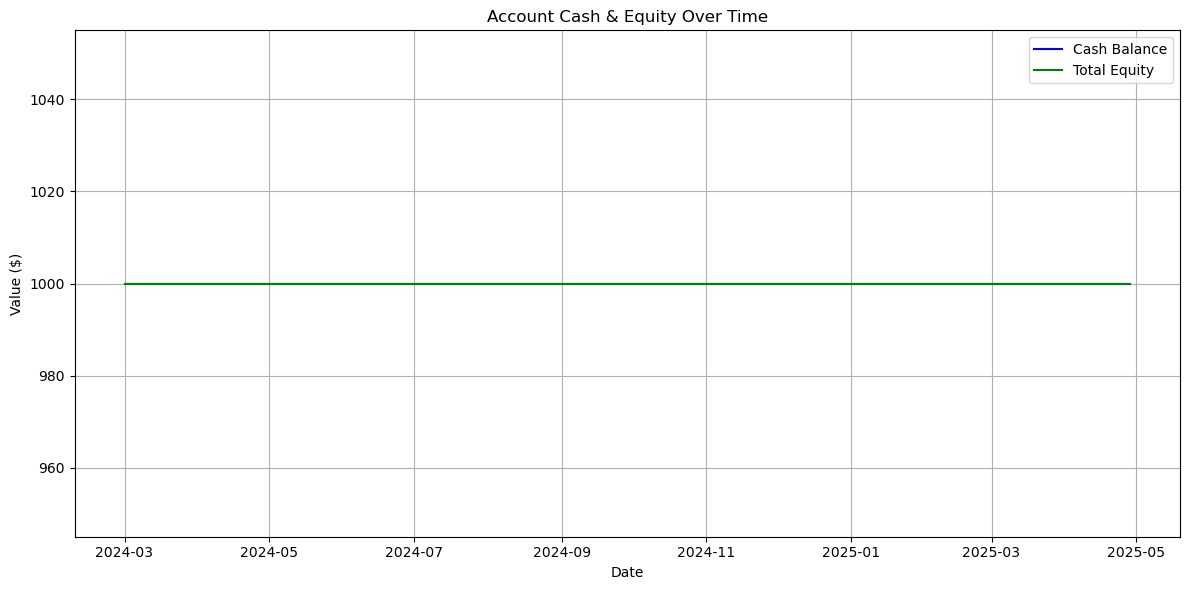

Empty DataFrame
Columns: []
Index: []
                       date  cash  equity
0 2024-03-01 05:00:00+00:00  1000    1000
1 2024-03-04 05:00:00+00:00  1000    1000
2 2024-03-05 05:00:00+00:00  1000    1000
3 2024-03-06 05:00:00+00:00  1000    1000
4 2024-03-07 05:00:00+00:00  1000    1000


In [7]:
from Butterfly_long_backtest import ButterflyBacktest



# Make sure your DataFrames are loaded and preprocessed:
# options_data, underlying_data, vol_predictions

# Instantiate the backtest class
bt = ButterflyBacktest(
    options_data=options_data,
    underlying_data=underlying_data,
    vol_predictions=vol_predictions,  
    spread_pct=1,                     # pct of the underlying price to set the spread width
    commission=1.0,                   # teke into account commission costs
    slippage=0.01,                    # take into account slippage
    min_open_interest=1,             # ensure sufficient open interest
    min_volume=1,                     # ensure sufficient liquidity
    vol_exit_threshold=10            # exit if the predicted volatility changes by more than this percentage
)

# Run the backtest
results_df, equity_df = bt.run(option_type='call', starting_cash=1000)

# Display results
print(results_df.head())
print(equity_df.head())

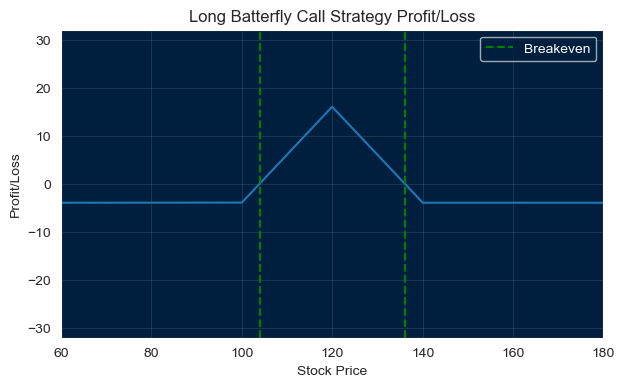

Net Cost/Credit: -3.9593731000237256
Profit if price will be between 103.95844395844395 and 136.04155604155605
Loss if price will be lower than 103.95844395844395 or higher than 136.04155604155605


In [ ]:
#------------------------------------------------
# # play with option strategy 
#-----------------------------------------------
from OptionStrategyfunctions import OptionStrategy

# OptionStrategy(Price_underlying,risk_free_rate = , days_to_maturity)


option = OptionStrategy(80,0.1,2)
sigma = 0.189 # adapt as dynamic rolling window (90 days?) 

option.long_butterfly_call(sigma, 100, 120, 140)

